# Cluster Summary — iGEM

Cluster-level summaries for iGEM teams topic model using year-based normalization (no citation metrics).

Output:
- `assets/reports/cluster_summary_igem.tsv`

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)

ASSETS = os.path.join('..', 'assets')
MODELS = os.path.join(ASSETS, 'topic_models')
REPORTS = os.path.join(ASSETS, 'reports')
os.makedirs(REPORTS, exist_ok=True)

In [2]:
# Load iGEM metadata and topic model outputs
igem = pd.read_csv(os.path.join(ASSETS, 'igem.txt'), sep='\t')
teams_doc_topics = pd.read_csv(os.path.join(MODELS, 'teams_doc_topics.txt'), sep='\t')
teams_topic_names = pd.read_csv(os.path.join(MODELS, 'teams_topic_names.txt'), sep='\t')

igem['Year_y'] = pd.to_numeric(igem['Year_y'], errors='coerce')
igem = igem.rename(columns={'Year_y': 'year'})

# Merge topic assignments and names
igem_topics = igem.merge(teams_doc_topics, on='UT', how='left')
igem_topics = igem_topics.merge(teams_topic_names[['topic', 'global_name']], on='topic', how='left')

print(f"iGEM rows: {len(igem_topics):,}")
print(f"Topics: {igem_topics['topic'].nunique()} (incl. outlier -1)")
igem_topics[['UT', 'year', 'topic', 'global_name']].head(3)

iGEM rows: 4,707
Topics: 161 (incl. outlier -1)


,UT,year,topic,global_name
0,5260,2024,22,Space Synthetic Biology
1,5794,2025,4,Synthetic Diagnostics and Forensics
2,4831,2023,119,Mercury Detection and Detoxification


In [3]:
# Compute year-normalized metrics by topic (exclude outlier -1)
igem_valid = igem_topics[(igem_topics['topic'] >= 0) & igem_topics['year'].notna()].copy()

max_year = int(igem_valid['year'].max())
igem_valid['is_recent'] = (igem_valid['year'] >= max_year - 4).astype(int)
igem_valid['year_rank'] = igem_valid['year'].rank(pct=True)

cluster_summary_igem = igem_valid.groupby('topic').agg(
    n_teams=('UT', 'nunique'),
    n_records=('UT', 'size'),
    avg_year=('year', 'mean'),
    median_year=('year', 'median'),
    year_std=('year', 'std'),
    min_year=('year', 'min'),
    max_year=('year', 'max'),
    price_index=('is_recent', 'mean'),
    avg_year_rank=('year_rank', 'mean'),
).reset_index()

cluster_summary_igem = cluster_summary_igem.merge(
    teams_topic_names[['topic', 'global_name']], on='topic', how='left'
)

if 'Countries' in igem_valid.columns:
    country_counts = (
        igem_valid.groupby('topic')['Countries']
        .apply(lambda x: x.fillna('').replace('', np.nan).dropna().nunique())
        .reset_index(name='n_countries')
    )
    cluster_summary_igem = cluster_summary_igem.merge(country_counts, on='topic', how='left')

out_igem = os.path.join(REPORTS, 'cluster_summary_igem.tsv')
cluster_summary_igem.to_csv(out_igem, sep='\t', index=False)

print(f"Clusters: {len(cluster_summary_igem)}")
print(f"Price Index window: {max_year-4}-{max_year}")
print(f"Saved: {out_igem}")
cluster_summary_igem.sort_values(['n_teams', 'avg_year_rank'], ascending=[False, False]).head(15)

Clusters: 161
Price Index window: 2021-2025
Saved: ../assets/reports/cluster_summary_igem.tsv


,topic,n_teams,n_records,avg_year,median_year,year_std,min_year,max_year,price_index,avg_year_rank,global_name,n_countries
0,0,148,148,2014.128378,2013.0,5.061903,2004,2025,0.141892,0.281013,Spatial and Stimuli-Responsive Gene Regulation,27
2,2,91,91,2018.131868,2018.0,4.389910,2008,2025,0.329670,0.485404,Environmental Monitoring and Bioremediation,26
4,4,90,90,2019.777778,2020.0,4.093782,2008,2025,0.466667,0.588396,Synthetic Diagnostics and Forensics,23
1,1,81,81,2020.814815,2021.0,3.439154,2012,2025,0.604938,0.651057,Plastic Biodegradation and Recycling,21
3,3,72,72,2020.680556,2022.5,4.175132,2009,2025,0.611111,0.650050,Bacterial Cancer Diagnostics and Therapy,20
9,9,68,68,2018.044118,2019.0,5.233172,2007,2025,0.411765,0.494753,Portable Environmental and Health Biosensors,25
5,5,65,65,2019.153846,2019.0,3.641045,2011,2025,0.353846,0.541410,Synthetic Biology Tools and Applications,16
13,13,64,64,2017.750000,2018.0,4.979322,2007,2025,0.328125,0.473801,Microbial Production of Bioenergy and Chemicals,18
15,15,58,58,2018.120690,2017.5,4.739078,2009,2025,0.310345,0.490790,Environmental Bioremediation and Pesticide Det...,18
6,6,58,58,2014.931034,2014.5,4.154313,2008,2025,0.086207,0.301237,Standardized Biological Parts and Engineering,11


Most recent topics (avg_year):
 topic                                  global_name  n_teams    avg_year  median_year  price_index  avg_year_rank
    97       Accessible Synthetic Biology Platforms       29 2022.517241       2023.0     0.758621       0.766196
   160              Eye Health and Vision Therapies       10 2022.500000       2023.0     0.800000       0.765434
   118        Microplastic Pollution Bioremediation       14 2022.285714       2023.0     0.785714       0.755031
   137       Sustainable Agriculture and Biocontrol       13 2022.153846       2022.0     0.769231       0.740820
   126         Neurodegenerative Disease Microbiome       13 2022.153846       2024.0     0.692308       0.746155
   141        Neurodegenerative Disease Diagnostics       10 2022.100000       2022.0     0.800000       0.733471
   124     Synthetic Biology for Society and Health       16 2021.937500       2023.5     0.750000       0.726889
    46                   Gut-Brain Axis Engineering      

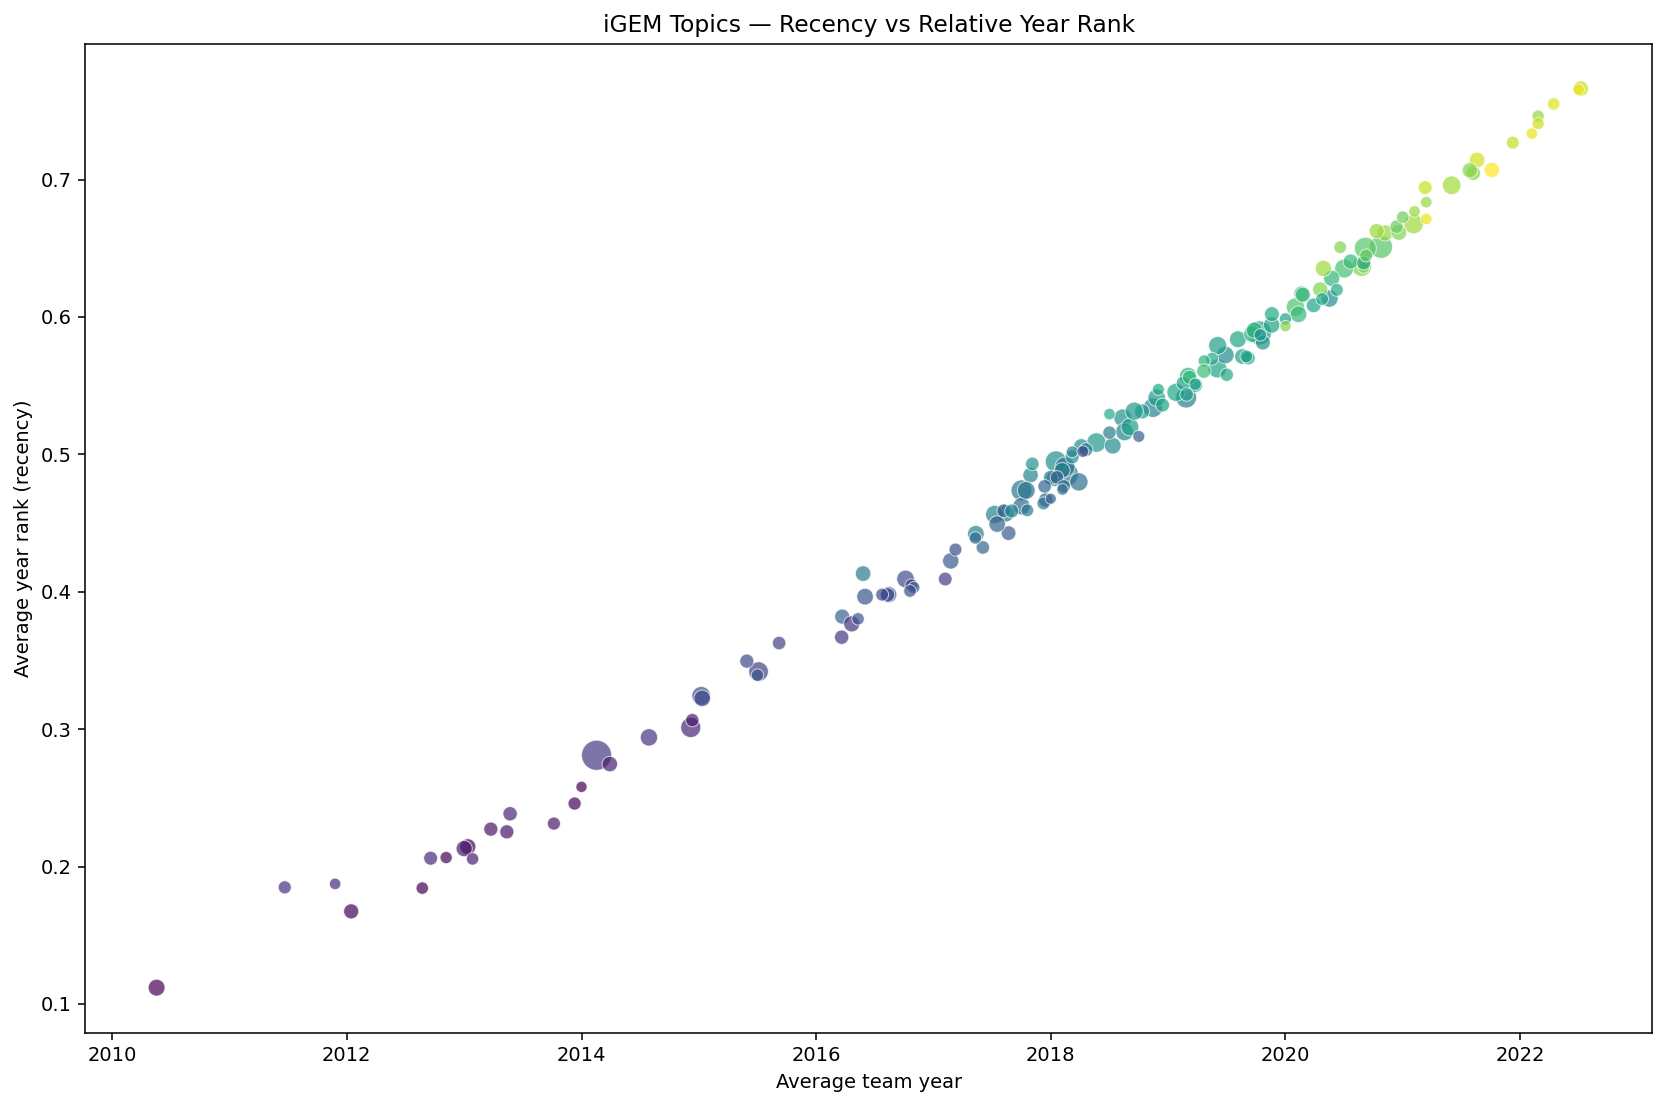

In [4]:
# Compact views: most recent and largest iGEM topics
print('Most recent topics (avg_year):')
display_cols = ['topic', 'global_name', 'n_teams', 'avg_year', 'median_year', 'price_index', 'avg_year_rank']
print(cluster_summary_igem.sort_values('avg_year', ascending=False)[display_cols].head(10).to_string(index=False))

print('\nLargest topics by teams:')
print(cluster_summary_igem.sort_values('n_teams', ascending=False)[display_cols].head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 8), dpi=140)
sizes = 20 + 220 * (cluster_summary_igem['n_teams'] / cluster_summary_igem['n_teams'].max())
ax.scatter(
    cluster_summary_igem['avg_year'],
    cluster_summary_igem['avg_year_rank'],
    s=sizes,
    alpha=0.7,
    edgecolors='white',
    linewidth=0.5,
    c=cluster_summary_igem['price_index'],
    cmap='viridis',
)
ax.set_xlabel('Average team year')
ax.set_ylabel('Average year rank (recency)')
ax.set_title('iGEM Topics — Recency vs Relative Year Rank')
plt.tight_layout()
plt.show()